by : Miftah Achmanda

Apa yang dilakukan pada code ini?

1. membaca setiap file sheet 'sales', 'expenses' dan maaping, dimana file tersebut berada pada gsheet yang berbeda.

url_sales = "https://docs.google.com/spreadsheets/d/1sWAv1ehEnWCUM5mYBQJl1QvEjurVu08vsBIGO9PTPB4/export?format=csv&gid=1488886954"

url_exp = "https://docs.google.com/spreadsheets/d/11Gq3ARHjhFfBewHqSNTVB-GBCZL1BBYaGzaBlRwFb7k/export?format=csv&gid=847693108"

url_map = "https://docs.google.com/spreadsheets/d/1SMr-GJsLJvCU1jWHVPdF0ZU9rwdKwVIqrWA-NCDPZyo/export?format=csv&gid=185342484"

1. preraration : dimana dilakukan normalisasi data agar sesuai bentuk tipe datanya, melakukan cleansing data, melakukan cek diplikat

2. Mengkombinasi data sales dan expenses
3. Membuat Monthly P&L
4. melakukan visualisasi


setelah code ini jadi, kemudian dimasukan pada extention apps sciprt yang ada pada file sheet untuk laporan, dimana file sheet ini merupakan hasil final setelah code dirunning. Bisa di cek pada speadsheet berikut.

https://docs.google.com/spreadsheets/d/1RuVrPx1rzdZ6Uvs_qYG0XEFQ7-rWRFDHNdxSyP_tc1Q/edit?usp=sharing

pada spreadsheet, terdapat hasil running code yang sudah dimasukan kedalam appscript, dimana menambilkan untuk sheet "Merge" yang merupakan hasil merge 'Sales' dan 'Expenxes' dan terdapat sheet 'Insight' dan 'Monthly P&L' dimana menampikan

- Revenue growth (MoM): 2.0%
- Expense growth (MoM): -4.8%
- Largest expense category (2025-09): 6400 = 36,870,389"

dan di sheet 'Monthly P&L' menampikan visualisasi dan tabelnya.


In [ ]:
import pandas as pd

url_sales = "https://docs.google.com/spreadsheets/d/1sWAv1ehEnWCUM5mYBQJl1QvEjurVu08vsBIGO9PTPB4/export?format=csv&gid=1488886954"
url_exp = "https://docs.google.com/spreadsheets/d/11Gq3ARHjhFfBewHqSNTVB-GBCZL1BBYaGzaBlRwFb7k/export?format=csv&gid=847693108"
url_map = "https://docs.google.com/spreadsheets/d/1SMr-GJsLJvCU1jWHVPdF0ZU9rwdKwVIqrWA-NCDPZyo/export?format=csv&gid=185342484"

sales = pd.read_csv(url_sales)
expenses = pd.read_csv(url_exp)
mapping = pd.read_csv(url_map)

print("Semua file berhasil di-load!")
sales.head()



Semua file berhasil di-load!


,Date,InvoiceNo,Product,Category,Quantity,UnitPrice,Customer,Region,Total
0,7/1/2025,INV1000,Pearl Earrings,Jewelry,1,450000,Customer E,Bali,450000
1,7/1/2025,INV1001,Silver Necklace,Jewelry,3,450000,Customer C,Bali,1350000
2,7/1/2025,INV1002,Pearl Earrings,Jewelry,4,450000,Customer E,Bandung,1800000
3,7/1/2025,INV1003,Pearl Earrings,Jewelry,2,350000,Customer D,Bali,700000
4,7/1/2025,INV1004,Titanium Ring,Jewelry,4,350000,Customer E,Medan,1400000


In [ ]:
import pandas as pd

# Melakukan Load dari file sales, expenses, dan mapping yang sudah ada pada sheet


SALES_ID = "1sWAv1ehEnWCUM5mYBQJl1QvEjurVu08vsBIGO9PTPB4"
SALES_GID = "1488886954"

EXP_ID = "11Gq3ARHjhFfBewHqSNTVB-GBCZL1BBYaGzaBlRwFb7k"
EXP_GID = "847693108"

MAP_ID = "1SMr-GJsLJvCU1jWHVPdF0ZU9rwdKwVIqrWA-NCDPZyo"
MAP_GID = "185342484"


# membaca file spreadsheet

def gsheet_to_df(sheet_id, gid):
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    return pd.read_csv(url)

# Load files
sales = gsheet_to_df(SALES_ID, SALES_GID)
expenses = gsheet_to_df(EXP_ID, EXP_GID)
mapping = gsheet_to_df(MAP_ID, MAP_GID)

print("Data berhasil di-load dari Google Sheets!")
sales


Data berhasil di-load dari Google Sheets!


,Date,InvoiceNo,Product,Category,Quantity,UnitPrice,Customer,Region,Total
0,7/1/2025,INV1000,Pearl Earrings,Jewelry,1,450000,Customer E,Bali,450000
1,7/1/2025,INV1001,Silver Necklace,Jewelry,3,450000,Customer C,Bali,1350000
2,7/1/2025,INV1002,Pearl Earrings,Jewelry,4,450000,Customer E,Bandung,1800000
3,7/1/2025,INV1003,Pearl Earrings,Jewelry,2,350000,Customer D,Bali,700000
4,7/1/2025,INV1004,Titanium Ring,Jewelry,4,350000,Customer E,Medan,1400000
...,...,...,...,...,...,...,...,...,...
882,9/30/2025,INV1882,Gold Bracelet,Jewelry,2,650000,Customer C,Surabaya,1300000
883,9/30/2025,INV1883,Gold Bracelet,Jewelry,2,450000,Customer D,Surabaya,900000
884,9/30/2025,INV1884,Pearl Earrings,Jewelry,4,450000,Customer B,Surabaya,1800000
885,9/30/2025,INV1885,Gold Bracelet,Jewelry,2,450000,Customer B,Jakarta,900000


In [ ]:
expenses


,Date,ExpenseType,Description,Amount
0,7/1/2025,Rent,Rent expense for operations,4524227
1,7/1/2025,Rent,Rent expense for operations,3549316
2,7/1/2025,Supplies,Supplies expense for operations,3049565
3,7/2/2025,Utilities,Utilities expense for operations,3460883
4,7/2/2025,Rent,Rent expense for operations,4607618
...,...,...,...,...
179,9/28/2025,Rent,Rent expense for operations,2615226
180,9/29/2025,Salaries,Salaries expense for operations,4130400
181,9/29/2025,Marketing,Marketing expense for operations,3354119
182,9/30/2025,Delivery,Delivery expense for operations,4097170


In [ ]:
sales.info()
expenses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       887 non-null    object
 1   InvoiceNo  887 non-null    object
 2   Product    887 non-null    object
 3   Category   887 non-null    object
 4   Quantity   887 non-null    int64 
 5   UnitPrice  887 non-null    int64 
 6   Customer   887 non-null    object
 7   Region     887 non-null    object
 8   Total      887 non-null    int64 
dtypes: int64(3), object(6)
memory usage: 62.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         184 non-null    object
 1   ExpenseType  184 non-null    object
 2   Description  184 non-null    object
 3   Amount       184 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 5.9+ KB


In [ ]:
#cek duplicate
sales.duplicated().value_counts()
expenses.duplicated().value_counts()

,count
False,184


# Data preparation

In [ ]:
import numpy as np

# melakukan normalisasi data columns
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

sales = normalize_cols(sales)
expenses = normalize_cols(expenses)
mapping = normalize_cols(mapping)

print("Kolom berhasil dinormalisasi!")


Kolom berhasil dinormalisasi!


In [ ]:
# merubah tipe data date,karena sebulmny masih object
if "date" in sales.columns:
    sales["date"] = pd.to_datetime(sales["date"], errors="coerce")

if "date" in expenses.columns:
    expenses["date"] = pd.to_datetime(expenses["date"], errors="coerce")


In [ ]:
# Menentukan kolom penting (tanggal, amount, kategori/akun)
def detect_date_col(df):
    # menemukan kolom tanggal
    for c in df.columns:
        if "date" in c:
            return c

    return df.columns[0]


def detect_amount_col(df):
    priority_keywords = ["amount", "total", "value", "price", "nominal"] # memilih kolom yang berisi angka

    for c in df.columns:
        if any(k in c for k in priority_keywords):
            return c
    return None


In [ ]:
# CLEAN SALES

# Convert date dan membuat colom baru "transaction_date"]
sales["transaction_date"] = pd.to_datetime(
    sales[detect_date_col(sales)], errors="coerce"
)

# Detect amount column
amt_sales = detect_amount_col(sales)

if amt_sales:
    # Konversi kolom tersebut menjadi tipe numerik
    sales["amount"] = pd.to_numeric(sales[amt_sales], errors="coerce")
elif {"unit_price", "quantity"}.issubset(sales.columns):

    # Jika kolom amount tidak ditemukan, tapi ada kolom "unit_price" dan "quantity": Maka jumlah/nominal dihitung sebagai unit_price * quantity
    sales["amount"] = (
        pd.to_numeric(sales["unit_price"], errors="coerce") *
        pd.to_numeric(sales["quantity"], errors="coerce")
    )
else:
    numeric_cols = sales.select_dtypes(include=np.number).columns
    sales["amount"] = sales[numeric_cols].iloc[:, 0] if len(numeric_cols) else np.nan

# Tag sales as revenue
sales["type"] = "revenue"


In [ ]:
# CLEAN EXPENSES
# sama seperti Clean sales

expenses["transaction_date"] = pd.to_datetime(
    expenses[detect_date_col(expenses)], errors="coerce"
)

amt_exp = detect_amount_col(expenses)

if amt_exp:
    expenses["amount"] = pd.to_numeric(expenses[amt_exp], errors="coerce")
else:
    numeric_cols = expenses.select_dtypes(include=np.number).columns
    expenses["amount"] = expenses[numeric_cols].iloc[:, 0] if len(numeric_cols) else np.nan

expenses["type"] = "expense"



In [ ]:
# REMOVE DUPLICATES

sales = sales.drop_duplicates().reset_index(drop=True)
expenses = expenses.drop_duplicates().reset_index(drop=True)

print("berhasil dibersihkan!")

berhasil dibersihkan!


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              887 non-null    datetime64[ns]
 1   invoiceno         887 non-null    object        
 2   product           887 non-null    object        
 3   category          887 non-null    object        
 4   quantity          887 non-null    int64         
 5   unitprice         887 non-null    int64         
 6   customer          887 non-null    object        
 7   region            887 non-null    object        
 8   total             887 non-null    int64         
 9   transaction_date  887 non-null    datetime64[ns]
 10  amount            887 non-null    int64         
 11  type              887 non-null    object        
dtypes: datetime64[ns](2), int64(4), object(6)
memory usage: 83.3+ KB


In [ ]:
expenses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              184 non-null    datetime64[ns]
 1   expensetype       184 non-null    object        
 2   description       184 non-null    object        
 3   amount            184 non-null    int64         
 4   transaction_date  184 non-null    datetime64[ns]
 5   type              184 non-null    object        
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 8.8+ KB


In [ ]:
#  EXTRACT DESCRIPTION
# membuat kolom descripsi
def extract_desc(df):
    desc_cols = [c for c in df.columns if "desc" in c or "item" in c or "name" in c]
    return df[desc_cols[0]].astype(str) if desc_cols else df.iloc[:, 0].astype(str)

sales["description"] = extract_desc(sales)
expenses["description"] = extract_desc(expenses)

sales.head()

,date,invoiceno,product,category,quantity,unitprice,customer,region,total,transaction_date,amount,type,description
0,2025-07-01,INV1000,Pearl Earrings,Jewelry,1,450000,Customer E,Bali,450000,2025-07-01,450000,revenue,2025-07-01
1,2025-07-01,INV1001,Silver Necklace,Jewelry,3,450000,Customer C,Bali,1350000,2025-07-01,450000,revenue,2025-07-01
2,2025-07-01,INV1002,Pearl Earrings,Jewelry,4,450000,Customer E,Bandung,1800000,2025-07-01,450000,revenue,2025-07-01
3,2025-07-01,INV1003,Pearl Earrings,Jewelry,2,350000,Customer D,Bali,700000,2025-07-01,350000,revenue,2025-07-01
4,2025-07-01,INV1004,Titanium Ring,Jewelry,4,350000,Customer E,Medan,1400000,2025-07-01,350000,revenue,2025-07-01


In [ ]:
# MAPPING COA

# menerapkan fungsi map_account ke kolom "description" di sales dan expenses
src_col = mapping.columns[0]
tgt_col = mapping.columns[1]

mapping2 = mapping.rename(columns={src_col: "source", tgt_col: "target"})
mapping2["source"] = mapping2["source"].astype(str).str.lower().str.strip()
mapping2["target"] = mapping2["target"].astype(str).str.strip()

def map_account(desc):
    desc = str(desc).lower()
    # exact match
    exact = mapping2[mapping2["source"] == desc]
    if len(exact):
        return exact["target"].iloc[0]
    # substring match
    for _, row in mapping2.iterrows():
        if row["source"] in desc:
            return row["target"]
    return "Unmapped"

sales["mapped_account"] = sales["description"].apply(map_account)
expenses["mapped_account"] = expenses["description"].apply(map_account)

print("Mapping COA selesai!")

Mapping COA selesai!


In [ ]:
#expenses["mapped_account"]

In [ ]:
#sales["mapped_account"]

# COMBINE SALES + EXPENSES

In [ ]:
# COMBINE SALES + EXPENSES

df = pd.concat([sales, expenses], ignore_index=True)
df["month"] = df["transaction_date"].dt.to_period("M").astype(str)

df


,date,invoiceno,product,category,quantity,unitprice,customer,region,total,transaction_date,amount,type,description,mapped_account,expensetype,month
0,2025-07-01,INV1000,Pearl Earrings,Jewelry,1.0,450000.0,Customer E,Bali,450000.0,2025-07-01,450000,revenue,2025-07-01,Unmapped,NaN,2025-07
1,2025-07-01,INV1001,Silver Necklace,Jewelry,3.0,450000.0,Customer C,Bali,1350000.0,2025-07-01,450000,revenue,2025-07-01,Unmapped,NaN,2025-07
2,2025-07-01,INV1002,Pearl Earrings,Jewelry,4.0,450000.0,Customer E,Bandung,1800000.0,2025-07-01,450000,revenue,2025-07-01,Unmapped,NaN,2025-07
3,2025-07-01,INV1003,Pearl Earrings,Jewelry,2.0,350000.0,Customer D,Bali,700000.0,2025-07-01,350000,revenue,2025-07-01,Unmapped,NaN,2025-07
4,2025-07-01,INV1004,Titanium Ring,Jewelry,4.0,350000.0,Customer E,Medan,1400000.0,2025-07-01,350000,revenue,2025-07-01,Unmapped,NaN,2025-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066,2025-09-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-28,2615226,expense,Rent expense for operations,6500,Rent,2025-09
1067,2025-09-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-29,4130400,expense,Salaries expense for operations,6300,Salaries,2025-09
1068,2025-09-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-29,3354119,expense,Marketing expense for operations,6100,Marketing,2025-09
1069,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-30,4097170,expense,Delivery expense for operations,6600,Delivery,2025-09


# Monthly P&L

In [ ]:
#Monthly P&L

monthly = (
    df.groupby(["month", "type"])
      .agg(total_amount=("amount", "sum"))
      .reset_index()
)

pivot = (
    monthly.pivot(index="month", columns="type", values="total_amount")
           .fillna(0)
           .reset_index()
)

# Pastikan kolom lengkap
if "revenue" not in pivot.columns:
    pivot["revenue"] = 0
if "expense" not in pivot.columns:
    pivot["expense"] = 0

pivot["gross_profit"] = pivot["revenue"] - pivot["expense"] #menghitung gross profit

print(" Monthly P&L berhasil dibuat!")
pivot


 Monthly P&L berhasil dibuat!


type,month,expense,revenue,gross_profit
0,2025-07,162071155,138650000,-23421155
1,2025-08,164949350,128800000,-36149350
2,2025-09,156984349,131400000,-25584349


In [ ]:
# Monthly by Account
# Menghitung total nilai transaksi untuk setiap akun (COA mapping) setiap bulan.

monthly_by_account = (
    df.groupby(["month", "mapped_account", "type"])
      .agg(total_amount=("amount", "sum"))
      .reset_index()
)

print(" Monthly by Account siap!")
monthly_by_account.head()


 Monthly by Account siap!


,month,mapped_account,type,total_amount
0,2025-07,6100,expense,27914634
1,2025-07,6200,expense,19726983
2,2025-07,6300,expense,34670841
3,2025-07,6400,expense,31380926
4,2025-07,6500,expense,23591530


# Visualisasi Trend & insight

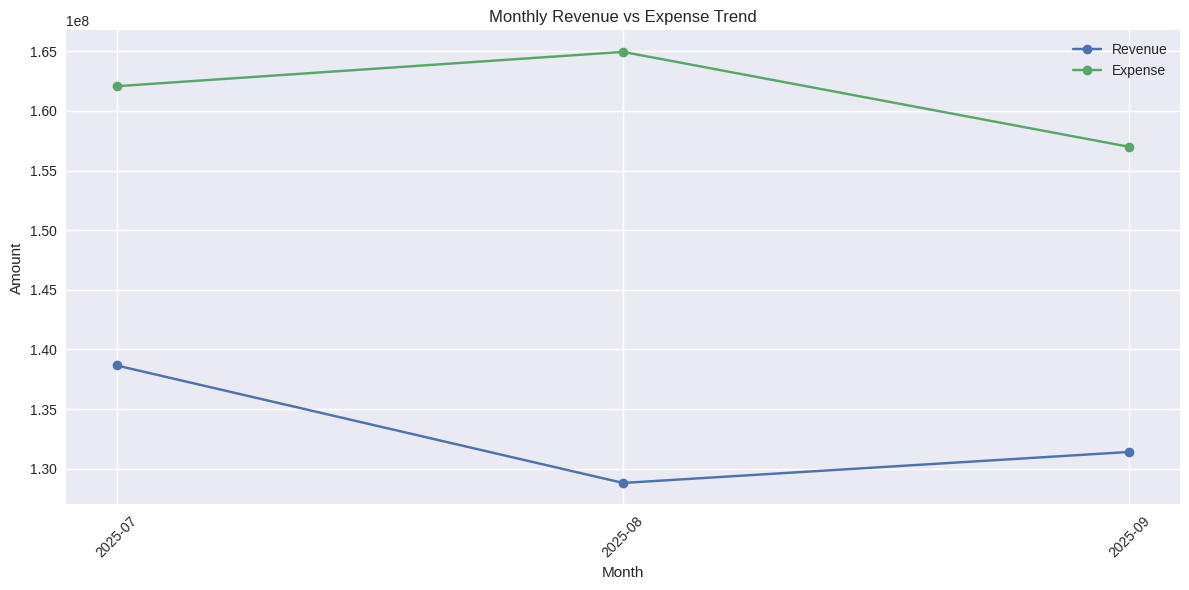

In [ ]:
#Visualisasi Trend

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(pivot["month"], pivot["revenue"], marker="o", label="Revenue")
plt.plot(pivot["month"], pivot["expense"], marker="o", label="Expense")

plt.title("Monthly Revenue vs Expense Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



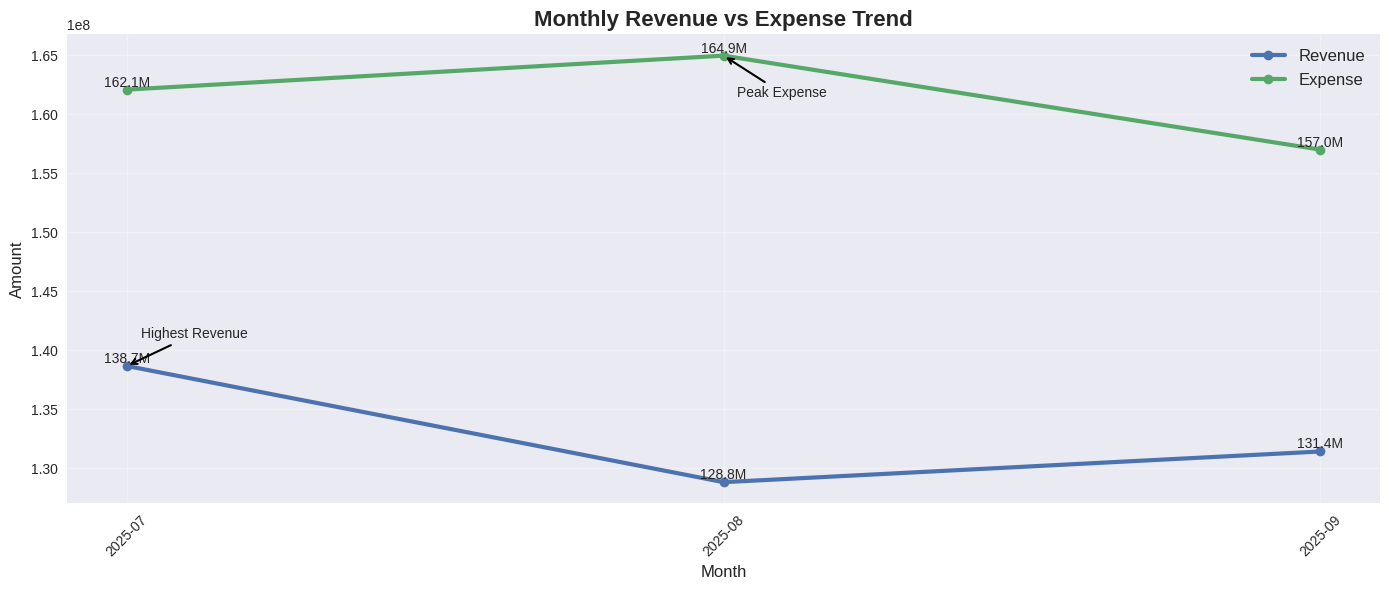

In [ ]:
import matplotlib.pyplot as plt

# Styling
plt.style.use("seaborn-v0_8")

months = pivot["month"]
revenue = pivot["revenue"]
expense = pivot["expense"]

plt.figure(figsize=(14, 6))

# Revenue line
plt.plot(months, revenue, marker="o", linewidth=3, label="Revenue")

# Expense line
plt.plot(months, expense, marker="o", linewidth=3, label="Expense")

# Add point labels
for i, val in enumerate(revenue):
    plt.text(months[i], val, f"{val/1e6:.1f}M", fontsize=10, ha='center', va='bottom')

for i, val in enumerate(expense):
    plt.text(months[i], val, f"{val/1e6:.1f}M", fontsize=10, ha='center', va='bottom')

# Find max/min and annotate
max_rev_idx = revenue.idxmax()
min_rev_idx = revenue.idxmin()

plt.annotate(
    "Highest Revenue",
    xy=(pivot.loc[max_rev_idx, "month"], pivot.loc[max_rev_idx, "revenue"]),
    xytext=(10, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

max_exp_idx = expense.idxmax()
plt.annotate(
    "Peak Expense",
    xy=(pivot.loc[max_exp_idx, "month"], pivot.loc[max_exp_idx, "expense"]),
    xytext=(10, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

# Chart formatting
plt.title("Monthly Revenue vs Expense Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Amount", fontsize=12)
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
# INSIGHTS AUTOMATIS

insights = []

if len(pivot) >= 2:
    latest = pivot.iloc[-1]
    prev = pivot.iloc[-2]

    # Revenue change
    if prev["revenue"] != 0:
        rev_change = (latest["revenue"] - prev["revenue"]) / prev["revenue"]
        insights.append(f"Revenue growth (MoM): {rev_change:.1%}")
    else:
        insights.append("Revenue growth (MoM): N/A")

    # Expense change
    if prev["expense"] != 0:
        exp_change = (latest["expense"] - prev["expense"]) / prev["expense"]
        insights.append(f"Expense growth (MoM): {exp_change:.1%}")
    else:
        insights.append("Expense growth (MoM): N/A")

    # Largest expense category
    last_month = pivot["month"].iloc[-1]
    exp_data = monthly_by_account[
        (monthly_by_account["month"] == last_month) &
        (monthly_by_account["type"] == "expense")
    ]

    if not exp_data.empty:
        top_exp = (
            exp_data.sort_values("total_amount", ascending=False)
                    .iloc[0]
        )
        insights.append(
            f"Largest expense category ({last_month}): "
            f"{top_exp['mapped_account']} = {top_exp['total_amount']:,}"
        )
else:
    insights.append("Not enough data for MoM analysis.")

# Tampilkan insights
print("INSIGHTS:")
for i in insights:
    print("-", i)


INSIGHTS:
- Revenue growth (MoM): 2.0%
- Expense growth (MoM): -4.8%
- Largest expense category (2025-09): 6400 = 36,870,389
